#**Telecom X – Parte 2: Prevendo Churn**

📌**Extração do Arquivo Tratado**

In [198]:
#Importando a biblioteca
import pandas as pd

In [199]:
#ler o arquivo csv tratado na parte 1 e salva na variavel dados
dados = pd.read_csv('/content/dados_tratados.csv')

In [200]:
#validando se carregou
dados

,id_cliente,Churn,genero,idoso,possui_parceiro,possui_dependentes,meses_contrato,servico_telefone,multiplas_linhas,servico_internet,...,suporte_tecnico,tv_streaming,filmes_streaming,tipo_contrato,fatura_online,forma_pagamento,gasto_mensal,gasto_total,contas_diarias,faixa_tempo_contrato
0,0002-ORFBO,0,Female,0,1,1,9,1,No,DSL,...,Yes,Yes,No,One year,1,Mailed check,65.60,593.30,2.186667,0-12
1,0003-MKNFE,0,Male,0,0,0,9,1,Yes,DSL,...,No,No,Yes,Month-to-month,0,Mailed check,59.90,542.40,1.996667,0-12
2,0004-TLHLJ,1,Male,0,0,0,4,1,No,Fiber optic,...,No,No,No,Month-to-month,1,Electronic check,73.90,280.85,2.463333,0-12
3,0011-IGKFF,1,Male,1,1,0,13,1,No,Fiber optic,...,No,Yes,Yes,Month-to-month,1,Electronic check,98.00,1237.85,3.266667,13-24
4,0013-EXCHZ,1,Female,1,1,0,3,1,No,Fiber optic,...,Yes,Yes,No,Month-to-month,1,Mailed check,83.90,267.40,2.796667,0-12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,9987-LUTYD,0,Female,0,0,0,13,1,No,DSL,...,Yes,No,No,One year,0,Mailed check,55.15,742.90,1.838333,13-24
7039,9992-RRAMN,1,Male,0,1,0,22,1,Yes,Fiber optic,...,No,No,Yes,Month-to-month,1,Electronic check,85.10,1873.70,2.836667,13-24
7040,9992-UJOEL,0,Male,0,0,0,2,1,No,DSL,...,No,No,No,Month-to-month,1,Mailed check,50.30,92.75,1.676667,0-12
7041,9993-LHIEB,0,Male,0,1,1,67,1,No,DSL,...,Yes,No,Yes,Two year,0,Mailed check,67.85,4627.65,2.261667,61-72


In [201]:
#validando se tem dados faltantes e tipos de colunas.
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id_cliente            7043 non-null   object 
 1   Churn                 7043 non-null   int64  
 2   genero                7043 non-null   object 
 3   idoso                 7043 non-null   int64  
 4   possui_parceiro       7043 non-null   int64  
 5   possui_dependentes    7043 non-null   int64  
 6   meses_contrato        7043 non-null   int64  
 7   servico_telefone      7043 non-null   int64  
 8   multiplas_linhas      7043 non-null   object 
 9   servico_internet      7043 non-null   object 
 10  seguranca_online      7043 non-null   object 
 11  backup_online         7043 non-null   object 
 12  protecao_dispositivo  7043 non-null   object 
 13  suporte_tecnico       7043 non-null   object 
 14  tv_streaming          7043 non-null   object 
 15  filmes_streaming     

In [202]:
dados.isnull().sum()

,0
id_cliente,0
Churn,0
genero,0
idoso,0
possui_parceiro,0
possui_dependentes,0
meses_contrato,0
servico_telefone,0
multiplas_linhas,0
servico_internet,0


nao temos valores nulos ou ausente

🧹**Remoção de Colunas Irrelevantes**

In [203]:
#id_cliente é apenas um identificador único. Não tem valor preditivo, então vou remover
dados = dados.drop('id_cliente', axis=1)

In [204]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Churn                 7043 non-null   int64  
 1   genero                7043 non-null   object 
 2   idoso                 7043 non-null   int64  
 3   possui_parceiro       7043 non-null   int64  
 4   possui_dependentes    7043 non-null   int64  
 5   meses_contrato        7043 non-null   int64  
 6   servico_telefone      7043 non-null   int64  
 7   multiplas_linhas      7043 non-null   object 
 8   servico_internet      7043 non-null   object 
 9   seguranca_online      7043 non-null   object 
 10  backup_online         7043 non-null   object 
 11  protecao_dispositivo  7043 non-null   object 
 12  suporte_tecnico       7043 non-null   object 
 13  tv_streaming          7043 non-null   object 
 14  filmes_streaming      7043 non-null   object 
 15  tipo_contrato        

In [205]:
dados.head()

,Churn,genero,idoso,possui_parceiro,possui_dependentes,meses_contrato,servico_telefone,multiplas_linhas,servico_internet,seguranca_online,...,suporte_tecnico,tv_streaming,filmes_streaming,tipo_contrato,fatura_online,forma_pagamento,gasto_mensal,gasto_total,contas_diarias,faixa_tempo_contrato
0,0,Female,0,1,1,9,1,No,DSL,No,...,Yes,Yes,No,One year,1,Mailed check,65.6,593.30,2.186667,0-12
1,0,Male,0,0,0,9,1,Yes,DSL,No,...,No,No,Yes,Month-to-month,0,Mailed check,59.9,542.40,1.996667,0-12
2,1,Male,0,0,0,4,1,No,Fiber optic,No,...,No,No,No,Month-to-month,1,Electronic check,73.9,280.85,2.463333,0-12
3,1,Male,1,1,0,13,1,No,Fiber optic,No,...,No,Yes,Yes,Month-to-month,1,Electronic check,98.0,1237.85,3.266667,13-24
4,1,Female,1,1,0,3,1,No,Fiber optic,No,...,Yes,Yes,No,Month-to-month,1,Mailed check,83.9,267.40,2.796667,0-12


🔧 **Encoding**

In [206]:
#importando as bibliotecas
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder

Separando as variaveis

In [207]:
x = dados.drop('Churn', axis = 1 ) #explicativa
y = dados['Churn'] #alvo

In [208]:
x

,genero,idoso,possui_parceiro,possui_dependentes,meses_contrato,servico_telefone,multiplas_linhas,servico_internet,seguranca_online,backup_online,...,suporte_tecnico,tv_streaming,filmes_streaming,tipo_contrato,fatura_online,forma_pagamento,gasto_mensal,gasto_total,contas_diarias,faixa_tempo_contrato
0,Female,0,1,1,9,1,No,DSL,No,Yes,...,Yes,Yes,No,One year,1,Mailed check,65.60,593.30,2.186667,0-12
1,Male,0,0,0,9,1,Yes,DSL,No,No,...,No,No,Yes,Month-to-month,0,Mailed check,59.90,542.40,1.996667,0-12
2,Male,0,0,0,4,1,No,Fiber optic,No,No,...,No,No,No,Month-to-month,1,Electronic check,73.90,280.85,2.463333,0-12
3,Male,1,1,0,13,1,No,Fiber optic,No,Yes,...,No,Yes,Yes,Month-to-month,1,Electronic check,98.00,1237.85,3.266667,13-24
4,Female,1,1,0,3,1,No,Fiber optic,No,No,...,Yes,Yes,No,Month-to-month,1,Mailed check,83.90,267.40,2.796667,0-12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Female,0,0,0,13,1,No,DSL,Yes,No,...,Yes,No,No,One year,0,Mailed check,55.15,742.90,1.838333,13-24
7039,Male,0,1,0,22,1,Yes,Fiber optic,No,No,...,No,No,Yes,Month-to-month,1,Electronic check,85.10,1873.70,2.836667,13-24
7040,Male,0,0,0,2,1,No,DSL,No,Yes,...,No,No,No,Month-to-month,1,Mailed check,50.30,92.75,1.676667,0-12
7041,Male,0,1,1,67,1,No,DSL,Yes,No,...,Yes,No,Yes,Two year,0,Mailed check,67.85,4627.65,2.261667,61-72


In [209]:
y

,Churn
0,0
1,0
2,1
3,1
4,1
...,...
7038,0
7039,1
7040,0
7041,0


Transformando as variáveis categóricas em formato numérico

In [210]:
#armazenar os nomes de todas as colunas
colunas = x.columns

In [211]:
#salvando uma variavel com os nomes das colunas que serao transformadas.
colunas_categoricas = [
    'genero',
    'multiplas_linhas',
    'servico_internet',
    'seguranca_online',
    'backup_online',
    'protecao_dispositivo',
    'suporte_tecnico',
    'tv_streaming',
    'filmes_streaming',
    'tipo_contrato',
    'forma_pagamento',
    'faixa_tempo_contrato'
]

In [212]:
#salvar a transformação em uma variavel.
one_hot = make_column_transformer(
    (OneHotEncoder(drop='if_binary'), colunas_categoricas),
    remainder='passthrough',
    sparse_threshold=0
)

In [213]:
#fazendo a transformação e salvando na mesma variavel;
x = one_hot.fit_transform(x)

In [214]:
#nomes das colunas gerou
nomes_colunas = one_hot.get_feature_names_out(colunas)

In [215]:
pd.DataFrame(x, columns = nomes_colunas)

,onehotencoder__genero_Male,onehotencoder__multiplas_linhas_No,onehotencoder__multiplas_linhas_No phone service,onehotencoder__multiplas_linhas_Yes,onehotencoder__servico_internet_DSL,onehotencoder__servico_internet_Fiber optic,onehotencoder__servico_internet_No,onehotencoder__seguranca_online_No,onehotencoder__seguranca_online_No internet service,onehotencoder__seguranca_online_Yes,...,onehotencoder__faixa_tempo_contrato_61-72,remainder__idoso,remainder__possui_parceiro,remainder__possui_dependentes,remainder__meses_contrato,remainder__servico_telefone,remainder__fatura_online,remainder__gasto_mensal,remainder__gasto_total,remainder__contas_diarias
0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,1.0,9.0,1.0,1.0,65.60,593.30,2.186667
1,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,9.0,1.0,0.0,59.90,542.40,1.996667
2,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,4.0,1.0,1.0,73.90,280.85,2.463333
3,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,...,0.0,1.0,1.0,0.0,13.0,1.0,1.0,98.00,1237.85,3.266667
4,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,...,0.0,1.0,1.0,0.0,3.0,1.0,1.0,83.90,267.40,2.796667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,13.0,1.0,0.0,55.15,742.90,1.838333
7039,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,22.0,1.0,1.0,85.10,1873.70,2.836667
7040,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,1.0,1.0,50.30,92.75,1.676667
7041,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,1.0,1.0,67.0,1.0,0.0,67.85,4627.65,2.261667


📌 **Verificação da Proporção de Evasão**

Calculando a proporção de clientes que evadiram em relação aos que permaneceram ativos para Avaliar se há desequilíbrio entre as classes.

In [216]:
y.value_counts(normalize = True)

,proportion
Churn,
0,0.73463
1,0.26537


Desequilíbrio detectado: a classe minoritária representa menos de 30% dos dados.

🎯 Correlação e Seleção de Variáveis

**Analise de Correlação**

In [217]:
# Correlação as correlações da variaveis numericas no conjunto de dados
corr = dados.corr(numeric_only=True)['Churn'].sort_values(ascending=False)
corr

,Churn
Churn,1.000000
gasto_mensal,0.193356
contas_diarias,0.193356
fatura_online,0.191825
idoso,0.150889
servico_telefone,0.011942
possui_parceiro,-0.150448
possui_dependentes,-0.164221
gasto_total,-0.198324
meses_contrato,-0.352229


**Análises Direcionadas**

In [114]:
import plotly.express as px

In [115]:
px.box(dados, x = 'gasto_mensal', color = 'Churn')

In [116]:
px.box(dados, x = 'meses_contrato', color = 'Churn')

In [150]:
px.box(dados, x = 'gasto_total', color = 'Churn')

**Separação de Dados**

In [118]:
from sklearn.model_selection import train_test_split

In [218]:
#70% treino 30%teste mantendo a mesma proporção de classes
x_treino, x_teste, y_treino, y_teste = train_test_split(x, y, stratify = y, test_size = 0.3, random_state = 5)

**Criação de Modelos**

Modelo Base (dummy) - Ele classifica todos os registros  com base na categoria da variável alvo de maior frequência

In [120]:
from sklearn.dummy import DummyClassifier

In [121]:
dummy = DummyClassifier()
dummy.fit(x_treino, y_treino)

dummy.score(x_teste, y_teste)

0.73450070989115

⚖️ **Balanceamento de Classes**

In [168]:
#Balancear os dados de treino
smote = SMOTE(random_state=5)
x_treino_balanceado, y_treino_balanceado = smote.fit_resample(x_treino, y_treino)

Modelo Arvore Decisão

In [169]:
from sklearn.tree import DecisionTreeClassifier
from imblearn.over_sampling import SMOTE

In [170]:
# Treinar o modelo de árvore
arvore = DecisionTreeClassifier(max_depth=3, random_state=5)
arvore.fit(x_treino_balanceado, y_treino_balanceado)

arvore.score(x_treino_balanceado, y_treino_balanceado)

0.7871341800110436

In [171]:
arvore.score(x_teste, y_teste)

0.7539044013251301

A diferença entre treino e teste é pequena. Sugere a árvore está capturando padrões reais dos dados, sem memorizar demais.

Modelo KNN

In [126]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier

Vou normalizar os dados porque na base tenho variáveis de gasto com valores contínuos e outras variáveis binárias (0 e 1).

a fim de evitar que variáveis como gasto_total (valores na casa dos milhares) dominem a distância.

Variáveis binárias (0 ou 1) teriam pouca influência na decisão do modelo

In [162]:
#Normalizar os dados
normalizacao = MinMaxScaler()
x_treino_normalizado = normalizacao.fit_transform(x_treino_balanceado)
x_teste_normalizado = normalizacao.transform(x_teste)

In [163]:
#Treinar o modelo
knn = KNeighborsClassifier()
knn.fit(x_treino_normalizado, y_treino_balanceado)

knn.score(x_treino_normalizado, y_treino_balanceado)

0.8564329099944782

In [164]:
knn.score(x_teste_normalizado, y_teste)

0.6881211547562707

**Avaliação dos Modelos**

In [130]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

In [165]:
#matriz de confusão
#dummy
y_previsto = dummy.predict(x_teste)
matriz_confusao_dummy = confusion_matrix(y_teste, y_previsto)
print(matriz_confusao_dummy)

[[1552    0]
 [ 561    0]]


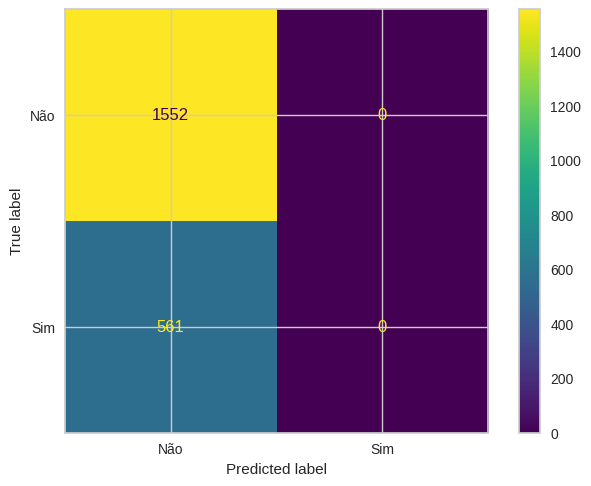

In [172]:
# Visualização dummy
visualizacao = ConfusionMatrixDisplay(confusion_matrix=matriz_confusao_dummy, display_labels=['Não', 'Sim'])
visualizacao.plot();

não detecta churn, mas é útil como referência mínima.

In [173]:
#matriz de confusão
#arvore
y_previsto = arvore.predict(x_teste)
matriz_confusao = confusion_matrix(y_teste, y_previsto)
print(matriz_confusao)

[[1186  366]
 [ 154  407]]


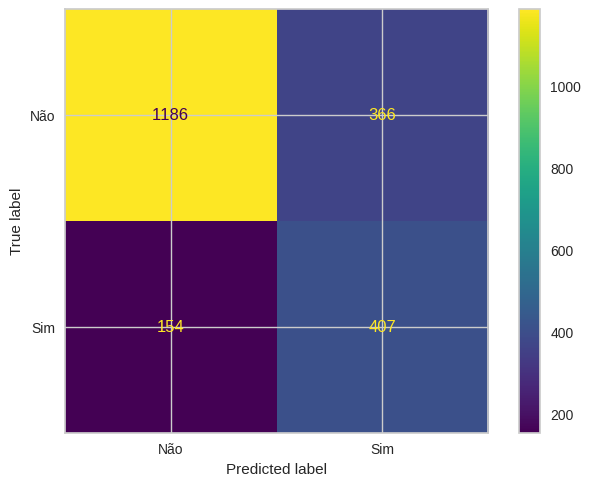

In [174]:
# Visualização arvore
visualizacao = ConfusionMatrixDisplay(confusion_matrix=matriz_confusao, display_labels=['Não', 'Sim'])
visualizacao.plot();

mais justo agora ele acerta mais a classe minoritária, mesmo que isso custe alguns erros na classe majoritária.

In [175]:
#matriz de confusão
#KNN
y_previsto = knn.predict(x_teste_normalizado)
matriz_confusao_KNN_norm = confusion_matrix(y_teste, y_previsto)
print(matriz_confusao_KNN_norm)

[[1035  517]
 [ 142  419]]


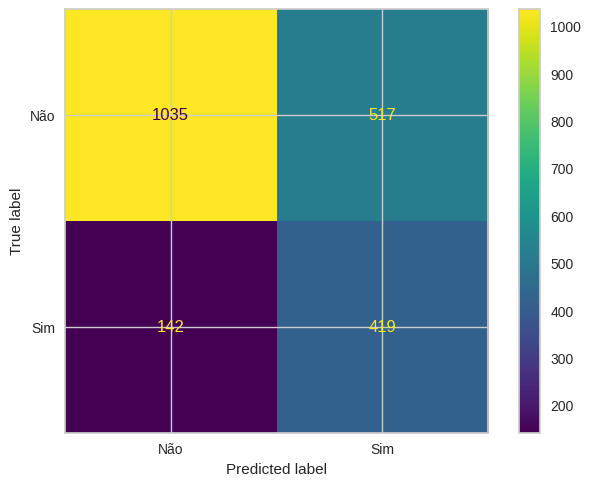

In [176]:
# Visualização arvore
visualizacao = ConfusionMatrixDisplay(confusion_matrix=matriz_confusao_KNN_norm, display_labels=['Não', 'Sim'])
visualizacao.plot();

após o balanceamento, ficou mais sensível à classe minoritária.

In [179]:
# Modelo 1 - Dummy
y_dummy = dummy.predict(x_teste)

# Modelo 2 - Árvore de Decisão
y_tree = arvore.predict(x_teste)

# Modelo 3 - KNN
y_knn = knn.predict(x_teste_normalizado)

In [180]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
import pandas as pd

resumo = {
    'Modelo': ['Dummy', 'Árvore', 'KNN'],
    'Acurácia': [
        accuracy_score(y_teste, y_dummy),
        accuracy_score(y_teste, y_tree),
        accuracy_score(y_teste, y_knn)
    ],
    'Precisão': [
        precision_score(y_teste, y_dummy, zero_division=0),
        precision_score(y_teste, y_tree),
        precision_score(y_teste, y_knn)
    ],
    'Recall': [
        recall_score(y_teste, y_dummy, zero_division=0),
        recall_score(y_teste, y_tree),
        recall_score(y_teste, y_knn)
    ],
    'F1 Score': [
        f1_score(y_teste, y_dummy, zero_division=0),
        f1_score(y_teste, y_tree),
        f1_score(y_teste, y_knn)
    ]
}

df_resultados = pd.DataFrame(resumo)
print(df_resultados.round(2))

   Modelo  Acurácia  Precisão  Recall  F1 Score
0   Dummy      0.73      0.00    0.00      0.00
1  Árvore      0.75      0.53    0.73      0.61
2     KNN      0.69      0.45    0.75      0.56


Dummy - Serve como baseline.

Árvore de Decisão - Melhor equilíbrio entre precisão e recall.

KNN - Maior recall - menos equilibrado que a árvore.

**Curva Roc**

In [181]:
from sklearn.metrics import RocCurveDisplay

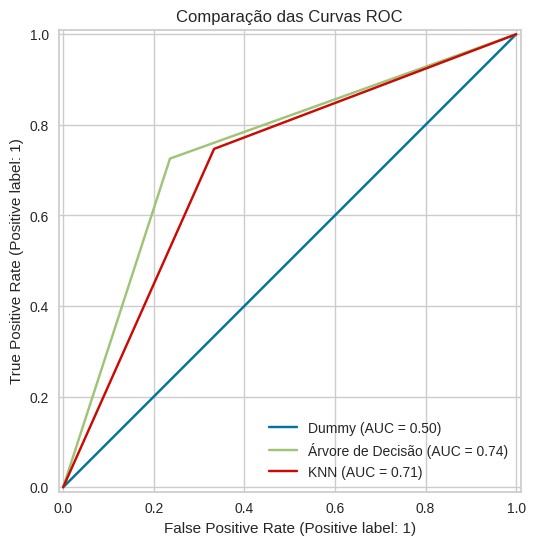

In [182]:
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay

# Criar figura e eixo compartilhado
fig, ax = plt.subplots(figsize=(8, 6))

# Plotar diretamente no mesmo eixo, sem gerar gráficos extras
RocCurveDisplay.from_predictions(y_teste, y_dummy, name='Dummy', ax=ax)
RocCurveDisplay.from_predictions(y_teste, y_tree, name='Árvore de Decisão', ax=ax)
RocCurveDisplay.from_predictions(y_teste, y_knn, name='KNN', ax=ax)

# Personalizar gráfico
plt.title('Comparação das Curvas ROC')
plt.grid(True)
plt.show()


In [183]:
from sklearn.metrics import roc_auc_score
print(f'AUC: {roc_auc_score(y_teste, y_dummy)}')
print(f'AUC: {roc_auc_score(y_teste, y_tree)}')
print(f'AUC: {roc_auc_score(y_teste, y_knn)}')

AUC: 0.5
AUC: 0.7448327269051951
AUC: 0.7068810068544756


A Árvore de Decisão continua sendo o modelo mais promissor:

O KNN ainda é uma alternativa, especialmente porque recall é prioridade, mas a árvore tem melhor performance geral.

**Curva de precisao e recall**

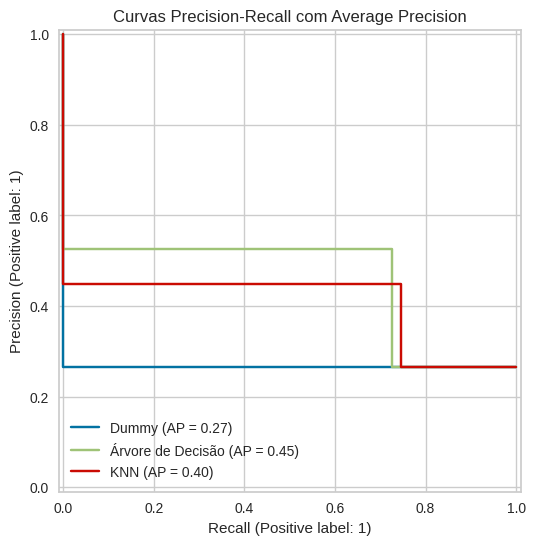

In [184]:
from sklearn.metrics import PrecisionRecallDisplay

# Criar figura e eixo compartilhado
fig, ax = plt.subplots(figsize=(8, 6))

# Plotar curvas PR diretamente no mesmo eixo
PrecisionRecallDisplay.from_predictions(
    y_teste, y_dummy, name='Dummy', ax=ax)

PrecisionRecallDisplay.from_predictions(
    y_teste, y_tree, name='Árvore de Decisão', ax=ax)

PrecisionRecallDisplay.from_predictions(
    y_teste, y_knn,name='KNN', ax=ax)

# Personalizar gráfico
plt.title('Curvas Precision-Recall com Average Precision')
plt.grid(True)
plt.show()


In [185]:
from sklearn.metrics import  average_precision_score

print(f'AP: {average_precision_score(y_teste, y_dummy)}')
print(f'AP: {average_precision_score(y_teste, y_tree)}')
print(f'AP: {average_precision_score(y_teste, y_knn)}')

AP: 0.26549929010885
AP: 0.45486729364984846
AP: 0.40154379703320436


Mais uma vez, a Árvore de Decisão se destaca:
ela é a mais equilibrada e eficaz para detectar a classe minoritária (evasão).

#Relatorio de metricas

In [144]:
from sklearn.metrics import classification_report

In [145]:
print(classification_report(y_teste, y_dummy,zero_division=0))
print(classification_report(y_teste, y_tree,zero_division=0))
print(classification_report(y_teste, y_knn,zero_division=0))

              precision    recall  f1-score   support

           0       0.73      1.00      0.85      1552
           1       0.00      0.00      0.00       561

    accuracy                           0.73      2113
   macro avg       0.37      0.50      0.42      2113
weighted avg       0.54      0.73      0.62      2113

              precision    recall  f1-score   support

           0       0.89      0.76      0.82      1552
           1       0.53      0.73      0.61       561

    accuracy                           0.75      2113
   macro avg       0.71      0.74      0.72      2113
weighted avg       0.79      0.75      0.76      2113

              precision    recall  f1-score   support

           0       0.88      0.67      0.76      1552
           1       0.45      0.75      0.56       561

    accuracy                           0.69      2113
   macro avg       0.66      0.71      0.66      2113
weighted avg       0.76      0.69      0.71      2113



A Árvore de Decisão continua sendo o modelo mais equilibrado:

Melhor precisão e F1-score para ambas as classes.

Maior weighted F1 e macro F1.

Detecta bem a classe minoritária sem sacrificar muito a classe majoritária.

#**Análise de Importância das Variáveis**

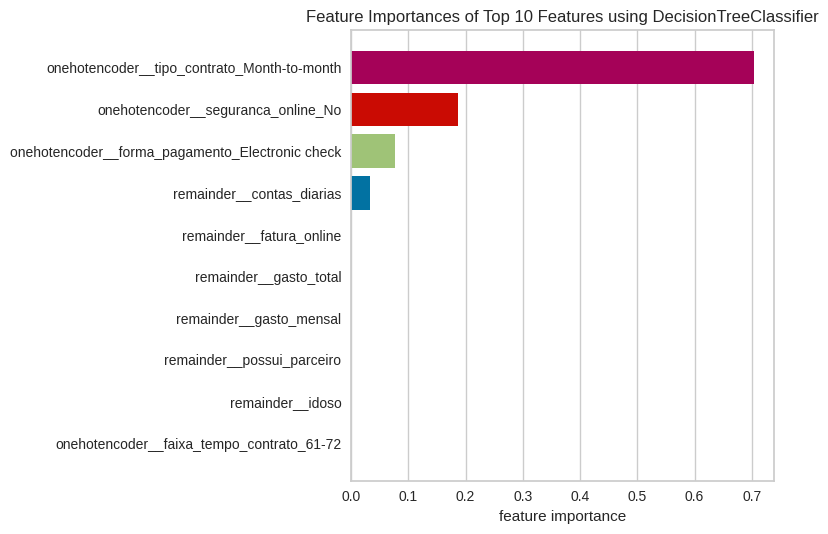

In [186]:
from yellowbrick.model_selection import FeatureImportances

#nomes das colunas gerou
x_treino_balanceado = pd.DataFrame(x_treino_balanceado, columns = nomes_colunas)

viz = FeatureImportances(arvore, relative=False, topn=10)
viz.fit(x_treino_balanceado, y_treino_balanceado)
viz.show()

# Garante que o gráfico seja exibido
plt.show()

In [187]:
importancias = pd.Series(arvore.feature_importances_, index=nomes_colunas)
print(importancias.sort_values(ascending=False).head(10))


onehotencoder__tipo_contrato_Month-to-month            0.703694
onehotencoder__seguranca_online_No                     0.186129
onehotencoder__forma_pagamento_Electronic check        0.076319
remainder__contas_diarias                              0.033857
onehotencoder__multiplas_linhas_Yes                    0.000000
onehotencoder__multiplas_linhas_No                     0.000000
onehotencoder__genero_Male                             0.000000
onehotencoder__servico_internet_No                     0.000000
onehotencoder__seguranca_online_No internet service    0.000000
onehotencoder__seguranca_online_Yes                    0.000000
dtype: float64


In [189]:
pd.crosstab(dados['tipo_contrato'], dados['Churn'], normalize='index')


Churn,0,1
tipo_contrato,,
Month-to-month,0.572903,0.427097
One year,0.887305,0.112695
Two year,0.971681,0.028319



Clientes com contrato mensal têm uma taxa de churn altíssima (42.7%), por isso o modelo está priorizando tipo_contrato_Month-to-month como uma das variáveis mais importantes.

In [197]:
from sklearn.inspection import permutation_importance

resultado = permutation_importance(knn, x_teste_normalizado, y_teste, n_repeats=10, random_state=5)

importancias = pd.Series(resultado.importances_mean, index=nomes_colunas)
print(importancias.sort_values(ascending=False).head(10))


onehotencoder__tipo_contrato_Month-to-month        0.009702
onehotencoder__tipo_contrato_One year              0.008897
onehotencoder__servico_internet_DSL                0.008803
onehotencoder__forma_pagamento_Mailed check        0.007525
onehotencoder__suporte_tecnico_Yes                 0.007004
onehotencoder__forma_pagamento_Electronic check    0.004685
onehotencoder__faixa_tempo_contrato_37-48          0.004307
onehotencoder__servico_internet_Fiber optic        0.004259
onehotencoder__faixa_tempo_contrato_49-60          0.003644
onehotencoder__seguranca_online_Yes                0.003407
dtype: float64


tipo_contrato continua sendo relevante, como vimos com a árvore.

servico_internet e forma_pagamento também têm impacto significativo.

Mesmo com normalização e balanceamento, o KNN está captando padrões similares aos da árvore — o que reforça que essas variáveis realmente têm valor preditivo

In [ ]:
📘 Relatório Final: Análise de Evasão de Clientes

#📘**Relatório Final: Análise de Evasão de Clientes**

🎯 **Objetivo**

O objetivo deste estudo foi identificar os principais fatores que influenciam a evasão de clientes (churn) em uma empresa de telecomunicações, utilizando modelos de machine learning e técnicas de interpretação de variáveis.

🧪 **Metodologia**

Foram aplicados os seguintes modelos de classificação:

**Árvore de Decisão**

**KNN**

Para avaliar a importância das variáveis, utilizei:

**Feature Importance da Árvore de Decisão**

**Permutation Importance com KNN**

As variáveis categóricas foram transformadas via **OneHotEncoding**, e o conjunto de dados foi **balanceado** para lidar com a desproporção entre clientes que evadiram e os que permaneceram.

#📊 **Principais Fatores que Influenciam a Evasão**

Com base nas análises dos dois modelos, trouxe 3 fatores que se destacaram:

**1. Tipo de Contrato**

*   Month-to-month (mensal) tem forte associação com evasão.
*   Clientes com contratos de um ano ou dois anos tendem a permanecer mais tempo.


**2. Forma de Pagamento**


*   Pagamentos via Mailed check e Electronic check estão mais associados à evasão.
*   Métodos automáticos como Bank transfer (automatic) indicam maior retenção.


**3. Serviço de Internet**

*   Clientes com Fiber optic apresentam maior taxa de evasão.
*   DSL está mais associado à permanência.




#**📈 Desempenho dos Modelos**

Ambos os modelos identificaram padrões semelhantes, reforçando a confiabilidade dos fatores destacados.

#**💡 Estratégias de Retenção**

Com base nos 3 fatores destacados, propomos as seguintes estratégias:

✅ **1. Incentivar Contratos de Longo Prazo**

*   Oferecer descontos ou benefícios para migração de contratos mensais para anuais ou bienais.

**✅ 2. Melhorar a Experiência com Pagamentos**


*   Promover o uso de pagamentos automáticos com incentivos.
*   Reduzir atritos em métodos como Mailed check.

**✅ 3. Monitorar Clientes com Fiber Optic**


*   Investigar causas de insatisfação com esse serviço.
*   Oferecer suporte técnico proativo e personalizado.



#**📌 Conclusão**

A análise revelou que o tipo de contrato, forma de pagamento, serviço de internet são os principais fatores que influenciam a evasão de clientes. A adoção de estratégias focadas nesses pontos pode aumentar significativamente a retenção e melhorar a experiência do cliente.